# Analyse rapide des données

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [8]:
data_train = pd.read_csv('../data/raw/application_train.csv', sep=',', na_values=[''], quotechar='"')

## Analyse du déséquilibre de classe

<Axes: ylabel='Frequency'>

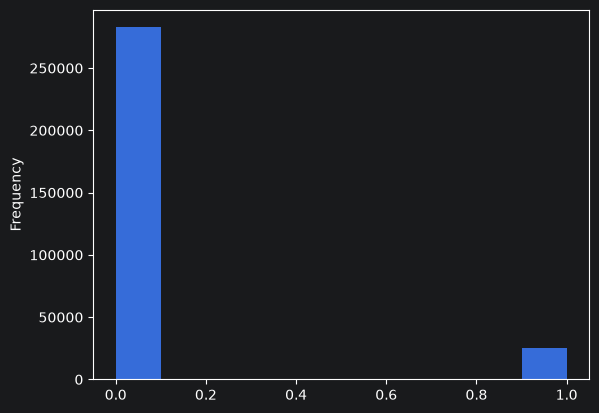

In [9]:
data_train['TARGET'].plot.hist()

## Analyse des colonnes vides

In [10]:
mis_val = data_train.isnull().sum()

# calculer le %age de cellules vides par colonne
mis_val_percent = 100 * data_train.isnull().sum() / len(data_train)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

mis_val_table.rename(columns={0: 'Missing Values', 1 : 'percentage'}, inplace=True)
mis_val_table = mis_val_table[mis_val_table['Missing Values'] > 0]
mis_val_table.sort_values(by='percentage', ascending=False, inplace=True)

print(mis_val_table)

                              Missing Values  percentage
COMMONAREA_MEDI                       214865   69.872297
COMMONAREA_AVG                        214865   69.872297
COMMONAREA_MODE                       214865   69.872297
NONLIVINGAPARTMENTS_MEDI              213514   69.432963
NONLIVINGAPARTMENTS_MODE              213514   69.432963
NONLIVINGAPARTMENTS_AVG               213514   69.432963
FONDKAPREMONT_MODE                    210295   68.386172
LIVINGAPARTMENTS_MODE                 210199   68.354953
LIVINGAPARTMENTS_MEDI                 210199   68.354953
LIVINGAPARTMENTS_AVG                  210199   68.354953
FLOORSMIN_MODE                        208642   67.848630
FLOORSMIN_MEDI                        208642   67.848630
FLOORSMIN_AVG                         208642   67.848630
YEARS_BUILD_MODE                      204488   66.497784
YEARS_BUILD_MEDI                      204488   66.497784
YEARS_BUILD_AVG                       204488   66.497784
OWN_CAR_AGE                    

In [11]:
data_train.duplicated('SK_ID_CURR').sum()

np.int64(0)

In [12]:
data_train_safe = data_train[data_train['TARGET'] == 0]
data_train_risk = data_train[data_train['TARGET'] == 1]

<Axes: ylabel='Frequency'>

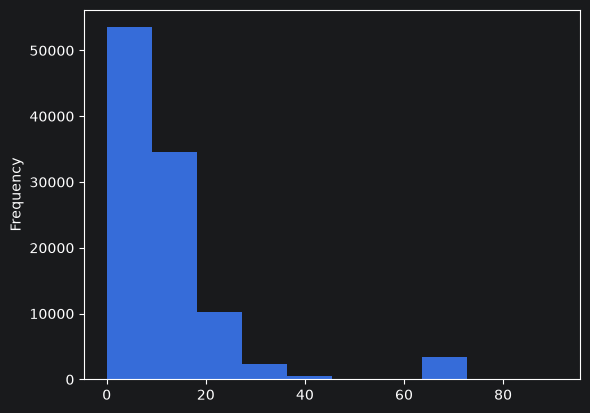

In [13]:
data_train['OWN_CAR_AGE'].plot.hist()

<Axes: ylabel='Frequency'>

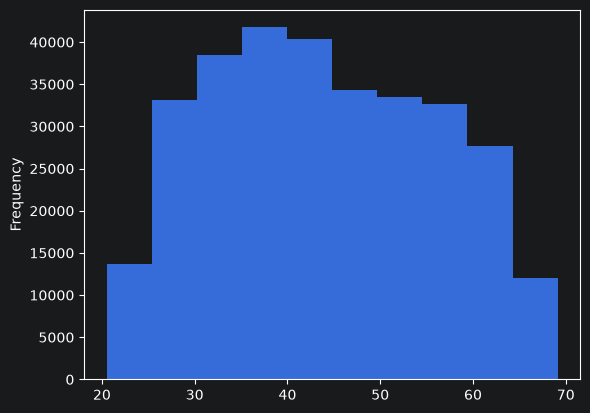

In [14]:
ages = abs(data_train['DAYS_BIRTH']) / 365
ages.plot.hist()

DAYS_BIRTH


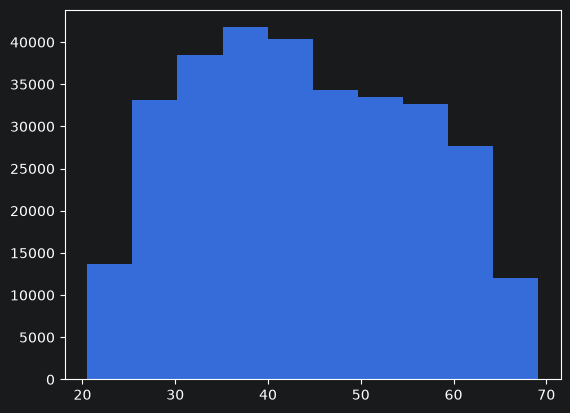

DAYS_EMPLOYED


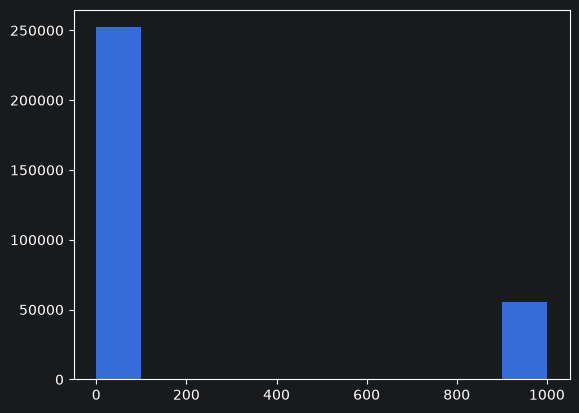

DAYS_REGISTRATION


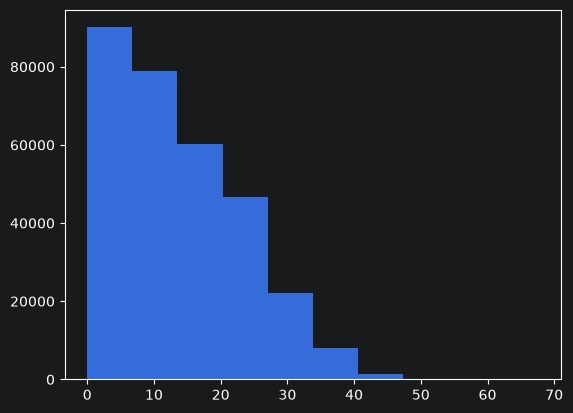

DAYS_ID_PUBLISH


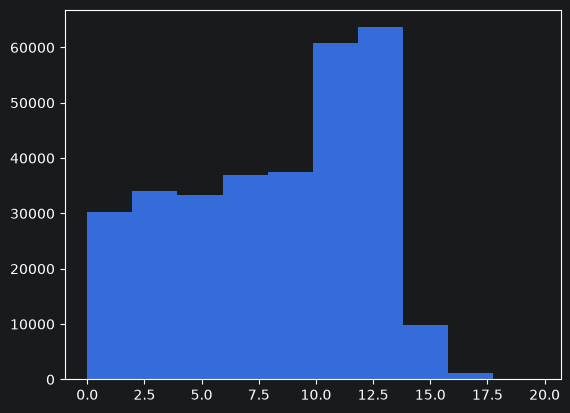

DAYS_LAST_PHONE_CHANGE


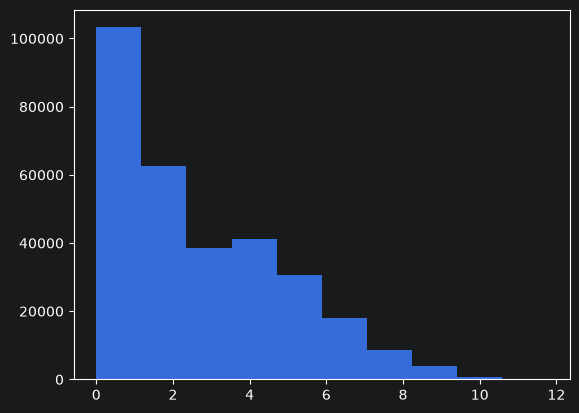

In [15]:
for col in data_train.columns:
    if "DAYS" in col:
        print(col)
        column_data_train = abs(data_train[col]) / 365
        plt.hist(column_data_train)
        plt.show()


<Axes: ylabel='Frequency'>

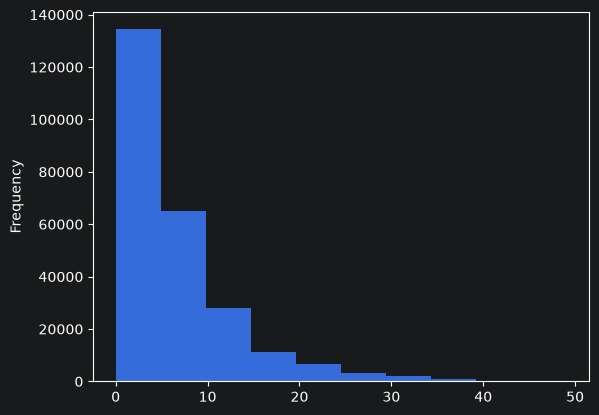

In [16]:
days_employed = data_train[data_train['DAYS_EMPLOYED'] < 350000]
(abs(days_employed['DAYS_EMPLOYED']) / 365).plot.hist()

<Axes: ylabel='Frequency'>

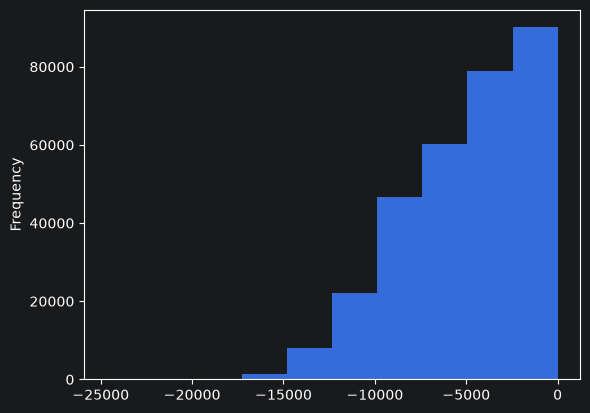

In [17]:
data_train['DAYS_REGISTRATION'].plot.hist()

In [18]:
a = data_train[data_train['OCCUPATION_TYPE'].isnull() & data_train['OCCUPATION_TYPE'].notnull()]

In [19]:
employed_age_outlier = data_train[data_train['DAYS_EMPLOYED'] == 365243]
employed_age_outlier

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
8,100011,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,913500.0,Children,Pensioner,Secondary / secondary special,Married,House / apartment,0.018634,-20099,365243,-7427.0,-3514,NaN,1,0,0,1,0,0,NaN,2.0,2,2,WEDNESDAY,14,0,0,0,0,0,0,XNA,0.587334,0.205747,0.751724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
11,100015,0,Cash loans,F,N,Y,0,38419.155,148365.0,10678.5,135000.0,Children,Pensioner,Secondary / secondary special,Married,House / apartment,0.015221,-20417,365243,-5246.0,-2512,NaN,1,0,0,1,1,0,NaN,2.0,2,2,FRIDAY,7,0,0,0,0,0,0,XNA,0.722044,0.555183,0.652897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-2396.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
23,100027,0,Cash loans,F,N,Y,0,83250.000,239850.0,23850.0,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.006296,-24827,365243,-9012.0,-3684,NaN,1,0,0,1,1,0,NaN,2.0,3,3,FRIDAY,12,0,0,0,0,0,0,XNA,NaN,0.624305,0.669057,0.1443,0.0848,0.9876,0.8300,0.1064,0.14,0.1207,0.3750,0.4167,0.2371,0.1173,0.1484,0.0019,0.0007,0.1261,0.0754,0.9876,0.8367,0.0000,0.1208,0.1034,0.3750,0.4167,0.2425,0.1102,0.0923,0.0000,0.0000,0.1457,0.0848,0.9876,0.8323,0.1071,0.14,0.1207,0.3750,0.4167,0.2412,0.1193,0.1510,0.0019,0.0007,org spec account,block of flats,0.1640,Mixed,No,0.0,0.0,0.0,0.0,-795.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
38,100045,0,Cash loans,F,N,Y,0,99000.000,2

<Axes: ylabel='Frequency'>

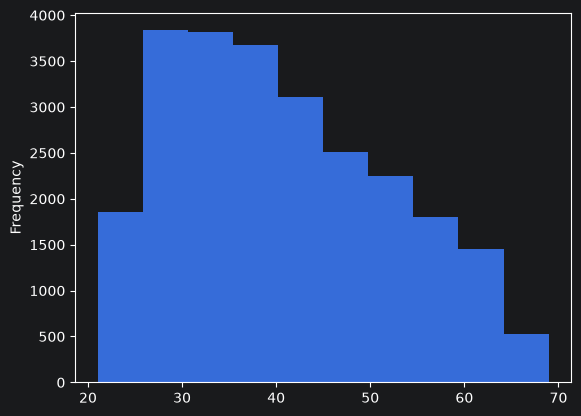

In [20]:
data_positive = data_train[data_train['TARGET'] == 1]

abs(data_positive['DAYS_BIRTH'] / 365).plot.hist()

In [21]:
bureau = pd.read_csv('../data/raw/bureau.csv', sep=',', na_values=[''], quotechar='"')

In [22]:
bureau['CREDIT_CURRENCY'].value_counts()

CREDIT_CURRENCY
currency 1    1715020
currency 2       1224
currency 3        174
currency 4         10
Name: count, dtype: int64

In [23]:
bureau['CREDIT_TYPE'].value_counts()

CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64

<Axes: >

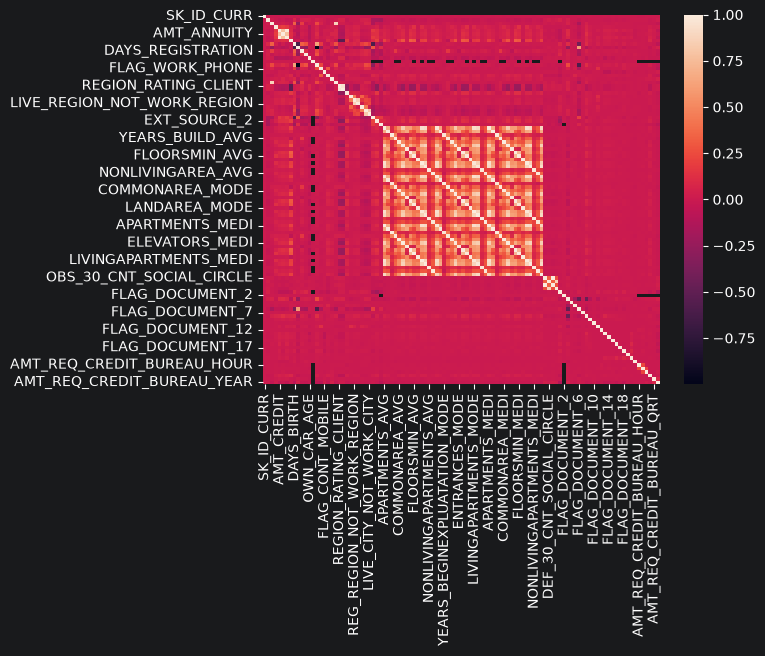

In [27]:
import seaborn as sns

numeric_data = data_train.select_dtypes(['int', 'float64'])

matrix = numeric_data.corr()

sns.heatmap(matrix)

## Analyse des features du fichier application_train

In [ ]:
refused_application = data_train[data_train['TARGET'] == 0]
accepted_application = data_train[data_train['TARGET'] == 1]

<Axes: xlabel='AMT_INCOME_TOTAL', ylabel='Count'>

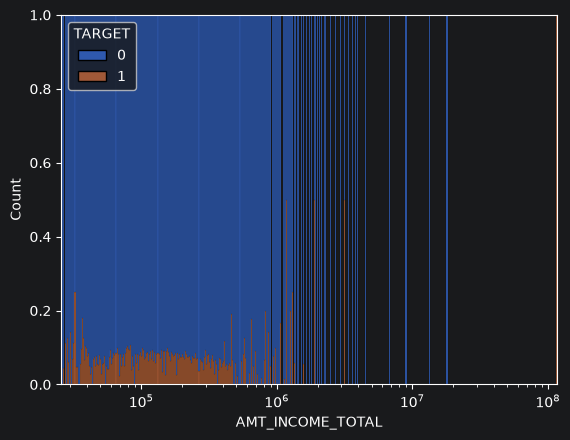

In [31]:
sns.histplot(data_train, x='AMT_INCOME_TOTAL', hue='TARGET', multiple='fill', log_scale=True)


In [ ]:
sns.histplot(data_train, x='AMT_INCOME_TOTAL', hue='TARGET', multiple='fill', log_scale=True)


<Axes: xlabel='FLAG_OWN_CAR', ylabel='Count'>

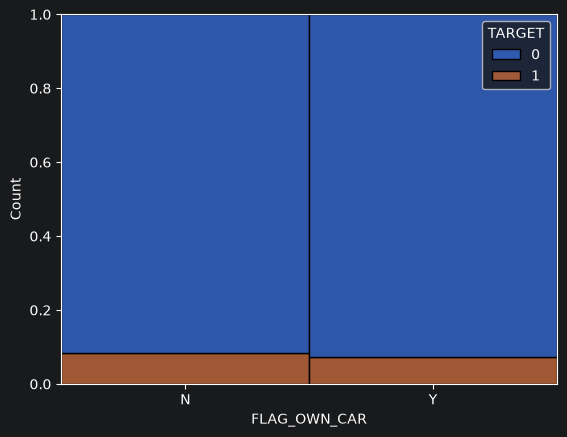

In [34]:
sns.histplot(data_train, x='FLAG_OWN_CAR', hue='TARGET', multiple='fill', log_scale=True)


<Axes: xlabel='OWN_CAR_AGE', ylabel='Count'>

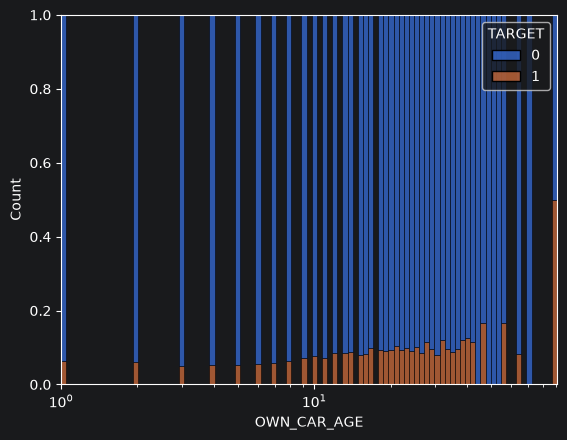

In [33]:
sns.histplot(data_train, x='OWN_CAR_AGE', hue='TARGET', multiple='fill', log_scale=True)

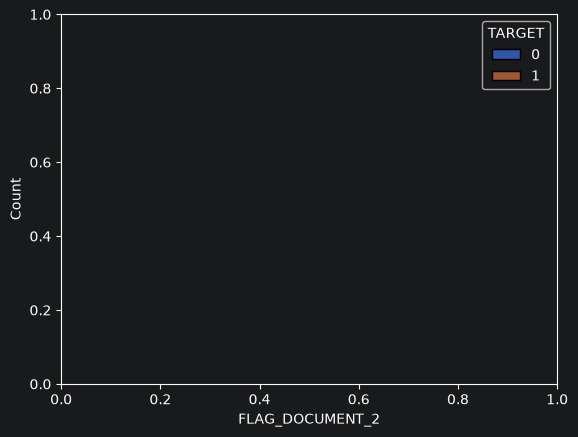

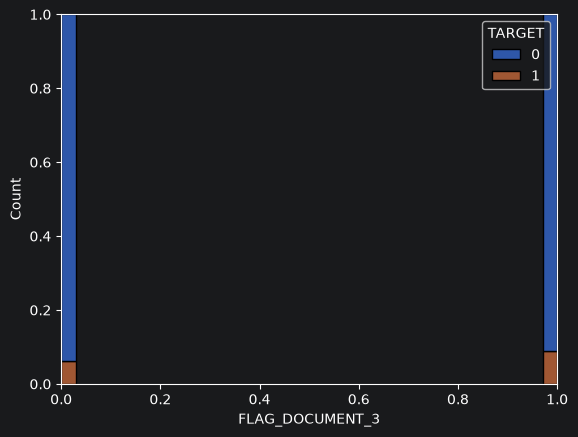

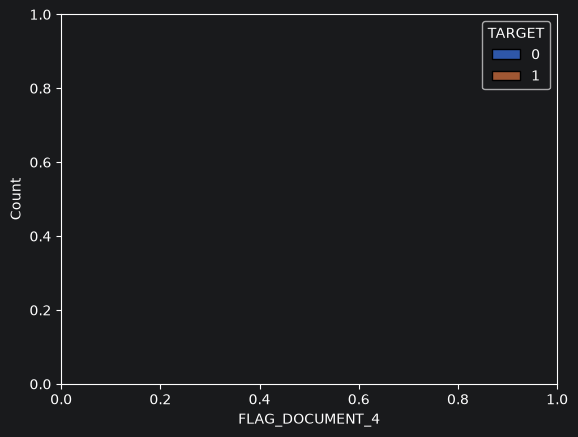

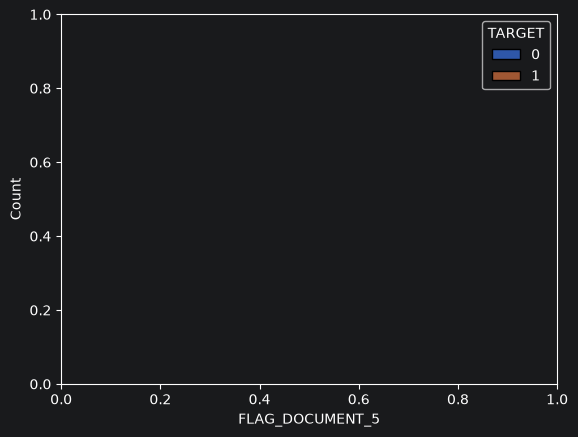

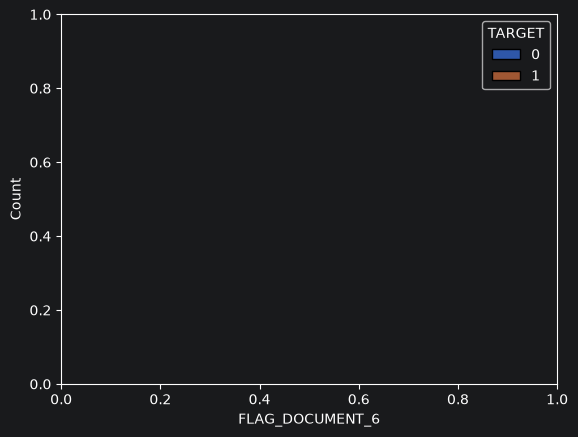

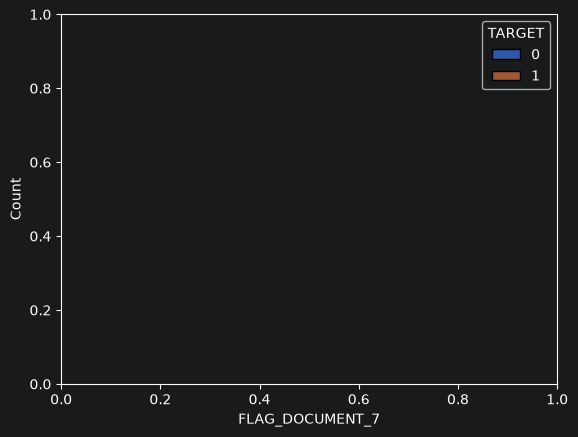

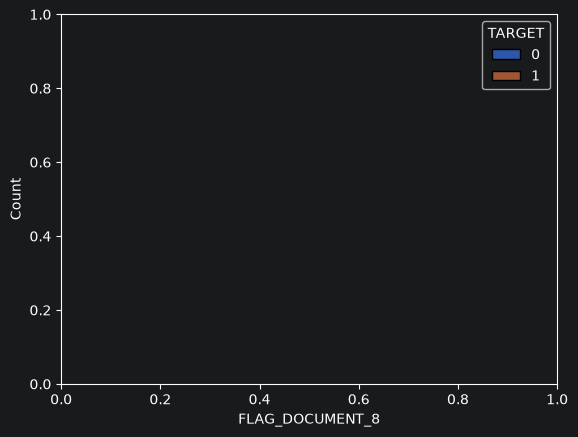

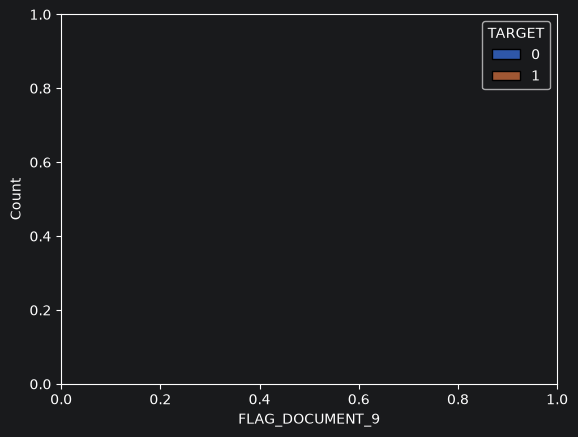

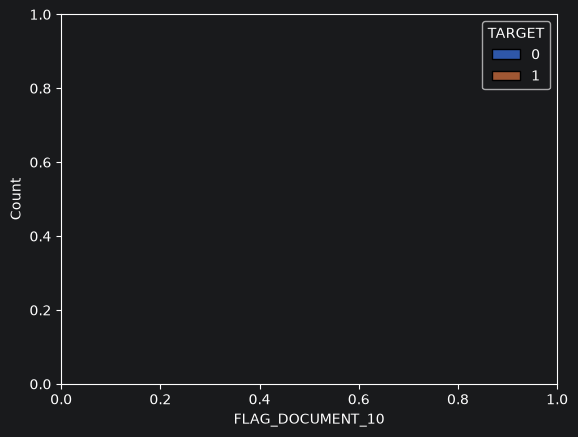

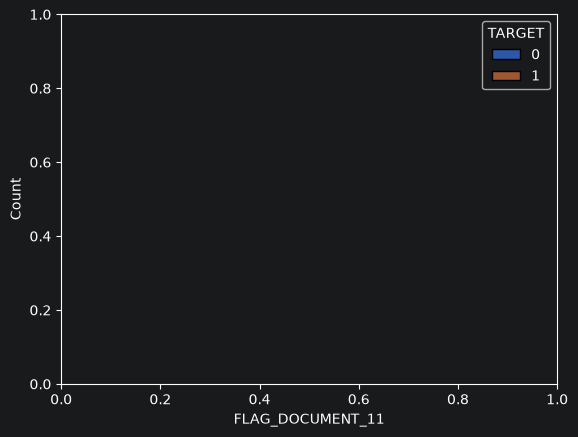

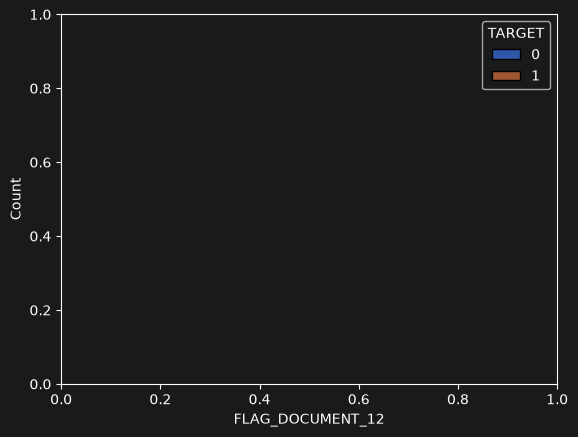

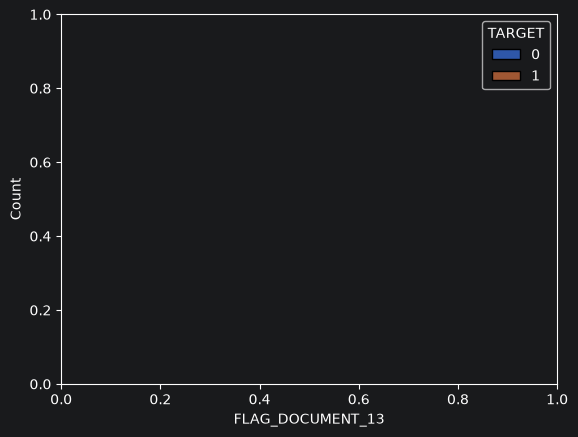

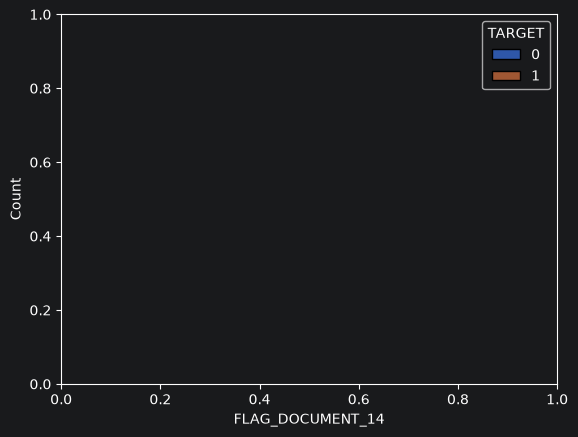

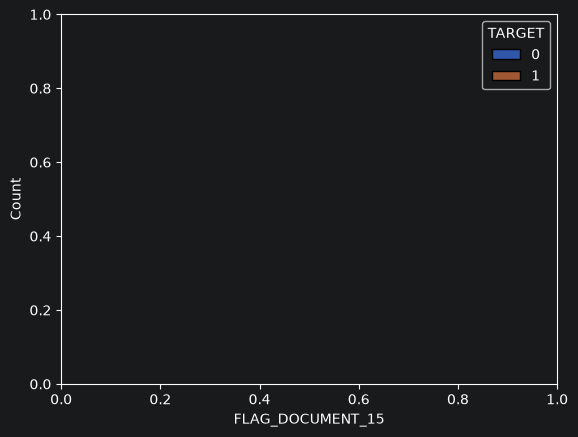

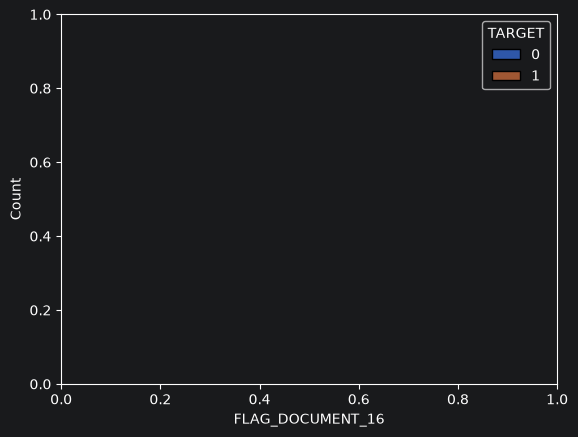

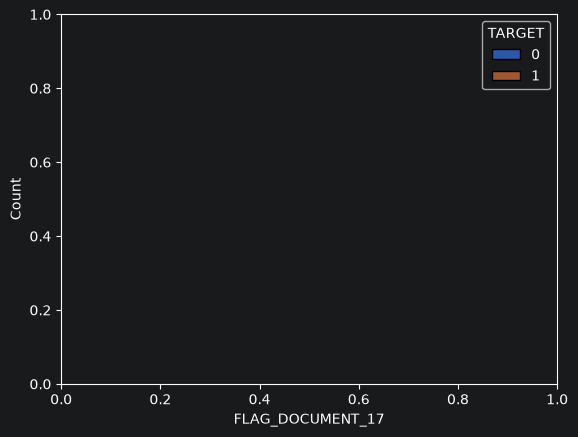

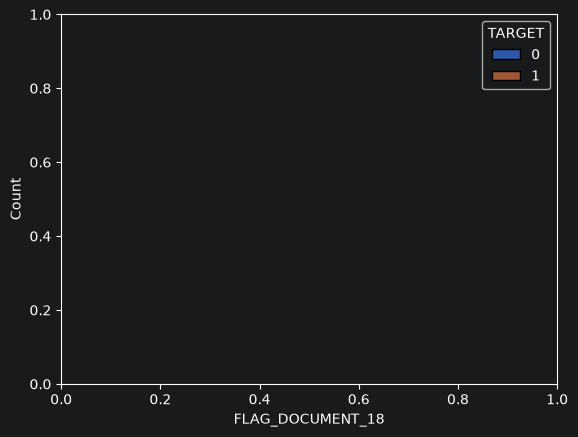

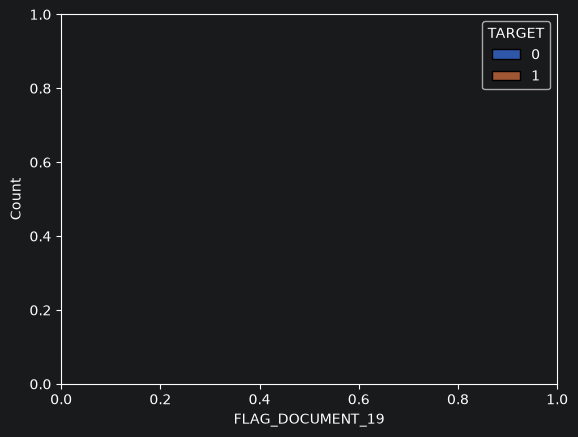

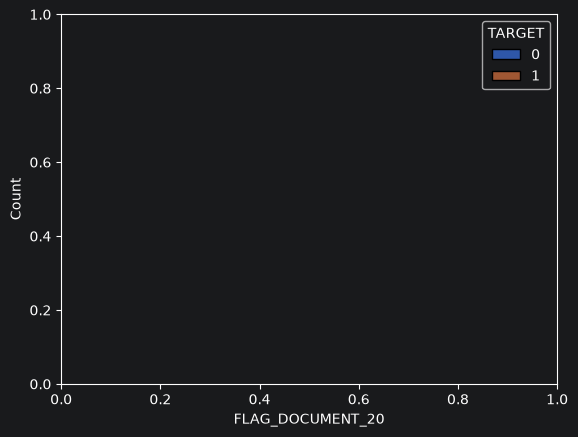

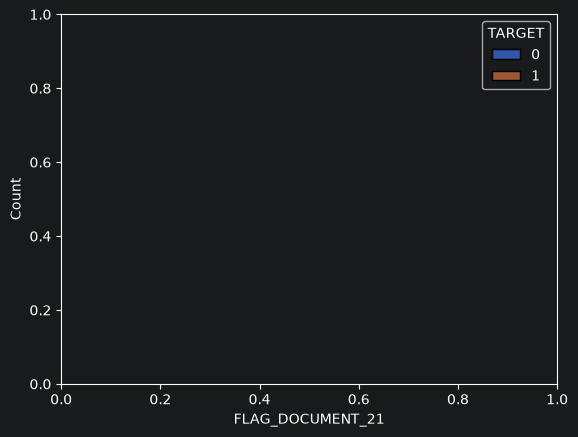

In [32]:
for i in range(2,22):
    columns_name = 'FLAG_DOCUMENT_' + str(i)
    sns.histplot(data_train, x=columns_name, hue='TARGET', multiple='fill')
    plt.show()

<Axes: xlabel='AGE', ylabel='Count'>

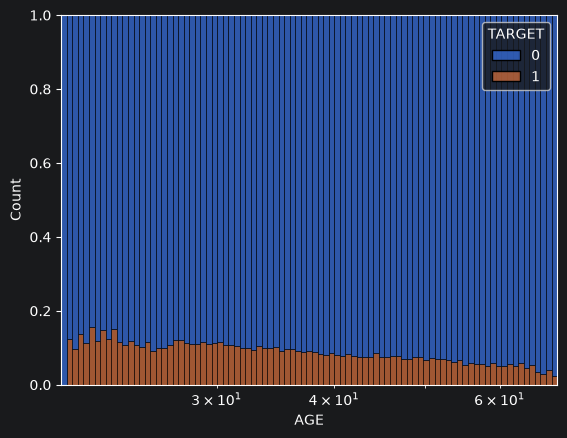

In [35]:
data_train['AGE'] = data_train['DAYS_BIRTH'] / -365.25
sns.histplot(data_train, x='AGE', hue='TARGET', multiple='fill', log_scale=True)

In [37]:
data_train['ratio_days_employed_vs_days_birth'] = data_train['DAYS_EMPLOYED'] / data_train['DAYS_BIRTH']
data_train['ratio_income_vs_credit'] = data_train['AMT_INCOME_TOTAL'] / data_train['AMT_CREDIT']
data_train['ratio_income_total_vs_fam_number'] = data_train['AMT_INCOME_TOTAL'] / data_train['CNT_FAM_MEMBERS']
data_train['ratio_annuity_vs_income_total'] = data_train['AMT_ANNUITY'] / data_train['AMT_INCOME_TOTAL']
data_train['ratio_children_vs_family'] = data_train['CNT_CHILDREN'] / data_train['CNT_FAM_MEMBERS']

<Axes: xlabel='ratio_days_employed_vs_days_birth', ylabel='Count'>

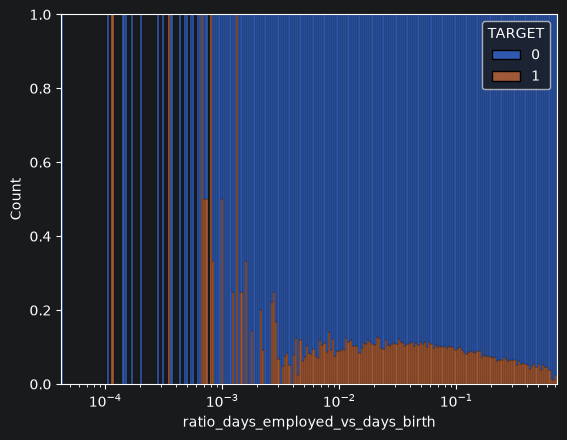

In [38]:
sns.histplot(data_train, x='ratio_days_employed_vs_days_birth', hue='TARGET', multiple='fill', log_scale=True)

<Axes: xlabel='ratio_income_vs_credit', ylabel='Count'>

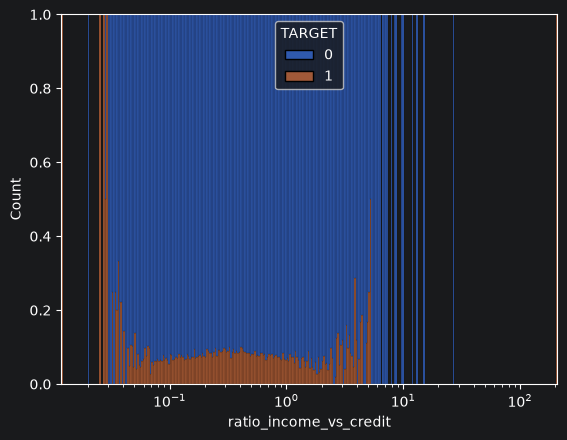

In [39]:
sns.histplot(data_train, x='ratio_income_vs_credit', hue='TARGET', multiple='fill', log_scale=True)

<Axes: xlabel='ratio_income_total_vs_fam_number', ylabel='Count'>

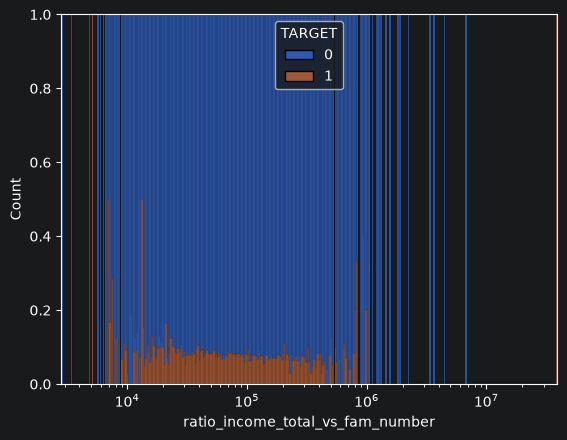

In [40]:
sns.histplot(data_train, x='ratio_income_total_vs_fam_number', hue='TARGET', multiple='fill', log_scale=True)

<Axes: xlabel='ratio_annuity_vs_income_total', ylabel='Count'>

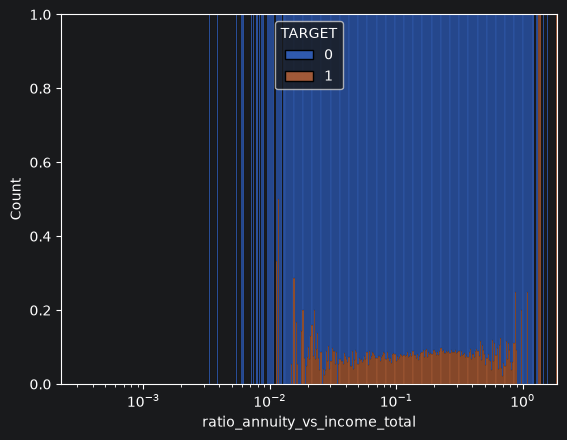

In [41]:
sns.histplot(data_train, x='ratio_annuity_vs_income_total', hue='TARGET', multiple='fill', log_scale=True)

<Axes: xlabel='ratio_children_vs_family', ylabel='Count'>

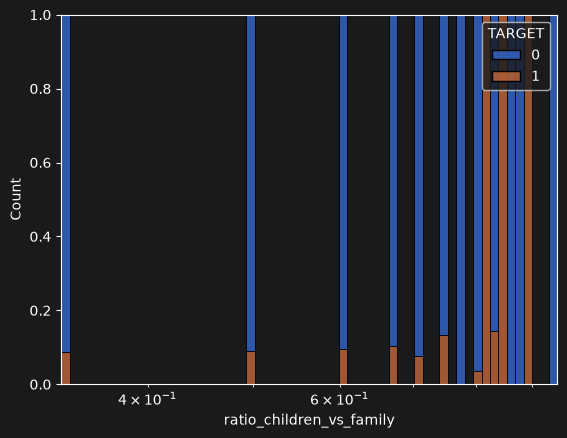

In [42]:
sns.histplot(data_train, x='ratio_children_vs_family', hue='TARGET', multiple='fill', log_scale=True)